In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

In [2]:
X_train = np.load("data/X_train.npy")
y_train = np.load("data/y_train.npy")
X_val = np.load("data/X_val.npy")
y_val = np.load("data/y_val.npy")

In [3]:
import tensorflow as tf
model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),
    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4,activation="softmax")
])

In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [6]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True)

In [7]:
model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=20,batch_size=32,callbacks=[early_stop])

Epoch 1/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 47s 447ms/step - accuracy: 0.6565 - loss: 0.8463 - val_accuracy: 0.8693 - val_loss: 0.3315
Epoch 2/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 42s 415ms/step - accuracy: 0.8387 - loss: 0.4205 - val_accuracy: 0.9223 - val_loss: 0.2569
Epoch 3/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 43s 420ms/step - accuracy: 0.8963 - loss: 0.2794 - val_accuracy: 0.9223 - val_loss: 0.2112
Epoch 4/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 43s 419ms/step - accuracy: 0.9354 - loss: 0.1921 - val_accuracy: 0.9260 - val_loss: 0.2054
Epoch 5/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 44s 430ms/step - accuracy: 0.9440 - loss: 0.1608 - val_accuracy: 0.9544 - val_loss: 0.1173
Epoch 6/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 44s 431ms/step - accuracy: 0.9581 - loss: 0.1106 - val_accuracy: 0.9420 - val_loss: 0.1621
Epoch 7/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 44s 433ms/step - accuracy: 0.9584 - loss: 0.1186 - val_accuracy: 0.9655 - val_loss: 0.1161
Epoch 8/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 44s 435ms/step - accuracy: 0.9668 - loss: 0

In [8]:
pred = model.predict(X_val)
pred_class = pred.argmax(axis=1)
print(np.unique(pred_class,return_counts=True))

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step
(array([0, 1, 2, 3]), array([218, 291, 217,  85]))


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

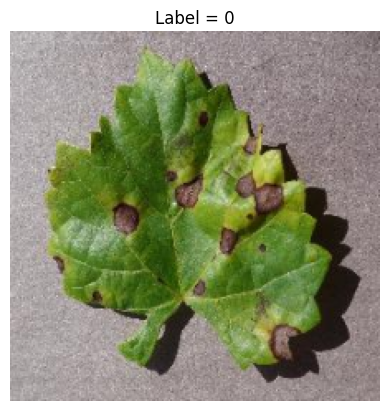

In [9]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])
plt.title(f"Label = {y_train[0]}")
plt.axis("off")

In [10]:
X_train[0].min(),X_train[0].max()

(np.float32(0.0), np.float32(0.9254902))